In [28]:
import numpy as np
import matplotlib.pyplot as plt
import torch 

In [29]:
from anomaly_detection.utils.load_sam_data import load_dataset
from anomaly_detection.utils.preprocess import drop_empty_histograms
from anomaly_detection.utils.preprocess import minmax_scale_per_sample

dataset = load_dataset("FJ")
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

Loading data from: C:\Users\hrdyj\coding\vyzkumak\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


In [30]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [31]:
full_dataset = torch.from_numpy(full_dataset)
full_dataset = full_dataset.to(torch.float32)

In [32]:
from anomaly_detection.config.paths import CHECKPOINT_DIR
from anomaly_detection.models.ano_gan_simplest import Generator, Discriminator, Encoder 
import os

checkpoint = torch.load(os.path.join(CHECKPOINT_DIR, "f_anogan_simplest_train_date=05-03_14-47.pth"), map_location="cpu")

generator = Generator()
discriminator = Discriminator()
encoder = Encoder()

generator.load_state_dict(checkpoint["generator"])
discriminator.load_state_dict(checkpoint["discriminator"])
encoder.load_state_dict(checkpoint["encoder"])

generator.eval()
discriminator.eval()
encoder.eval()

Encoder(
  (fc1): Linear(in_features=96, out_features=80, bias=True)
  (fc2): Linear(in_features=80, out_features=64, bias=True)
  (fc3): Linear(in_features=64, out_features=44, bias=True)
  (fc4): Linear(in_features=44, out_features=30, bias=True)
)

In [33]:
g_trainable_params = sum(p.numel() for p in generator.parameters() if p.requires_grad)
d_trainable_params = sum(p.numel() for p in discriminator.parameters() if p.requires_grad)
e_trainable_params = sum(p.numel() for p in encoder.parameters() if p.requires_grad)

print("Generator consists of", g_trainable_params, "trainable parameters.")
print("Disc consists of", d_trainable_params, "trainable parameters.")
print("Encoder consists of", e_trainable_params, "trainable parameters.")

Generator consists of 17220 trainable parameters.
Disc consists of 46441 trainable parameters.
Encoder consists of 17154 trainable parameters.


In [45]:
preds = []

with torch.no_grad():
    for idx, data in enumerate(full_dataset):
        pred = generator(encoder(data.reshape(1, 1, 96))).cpu().numpy().squeeze()
        
        for p in preds:
            if np.array_equal(pred, p):
                break
        else:
            preds.append(pred)

print(f"There are {len(preds)} unique representations that model outputs")

There are 613 unique representations that model outputs


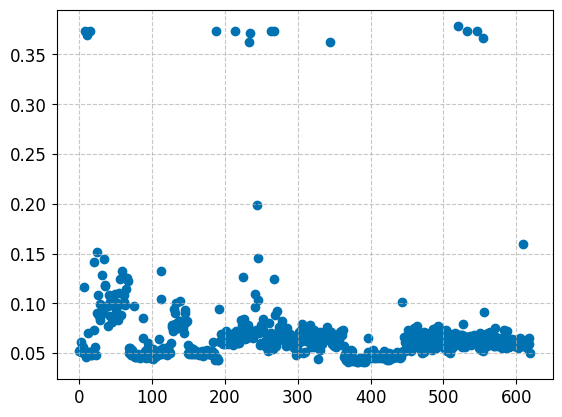

In [34]:
from anomaly_detection.models.ano_gan_v1 import anomaly_score
from anomaly_detection.utils.plotting_styles import apply_global_style

scores = []
for pt in full_dataset:
    pt = pt.reshape(1,1,96)
    scores.append(anomaly_score(pt, generator, discriminator, encoder).detach().numpy())

apply_global_style()
plt.scatter(range(len(full_dataset)), scores)

In [35]:
import pandas as pd 
from anomaly_detection.config.paths import DATA_DIR
import os

eval_df = pd.read_parquet(os.path.join(DATA_DIR, 'eval_data', 'eval_dataset.parquet'))

In [36]:
eval_score = []
for pt in eval_df['histogram']:
    pt = torch.tensor(pt).to(torch.float32).reshape(1, 1, 96)
    eval_score.append(anomaly_score(pt, generator, discriminator, encoder).detach().numpy())

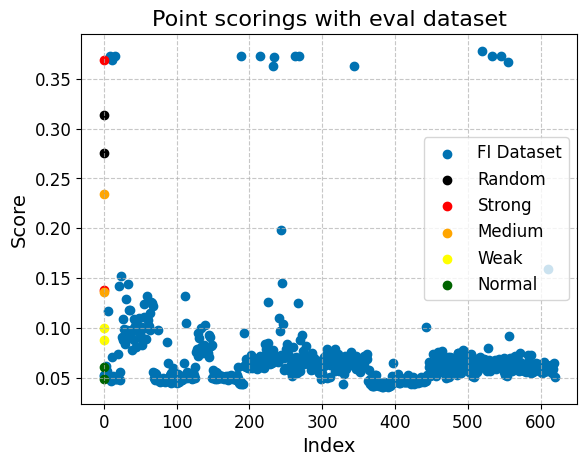

In [37]:
from anomaly_detection.utils.plotting_styles import apply_global_style
apply_global_style()
plt.title("Point scorings with eval dataset")
plt.scatter(range(len(scores)), scores, label='FI Dataset')
plt.scatter(range(len(eval_score[:2])), eval_score[:2], color='black', label='Random')
plt.scatter(range(len(eval_score[2:4])), eval_score[2:4], color='red', label='Strong')
plt.scatter(range(len(eval_score[4:6])), eval_score[4:6], color='orange', label='Medium')
plt.scatter(range(len(eval_score[6:8])), eval_score[6:8], color='yellow', label='Weak')
plt.scatter(range(len(eval_score[8:])), eval_score[8:], color='darkgreen', label='Normal')
plt.xlabel('Index')
plt.ylabel("Score")
plt.legend()

In [38]:
idx = 244
pt = full_dataset[idx]

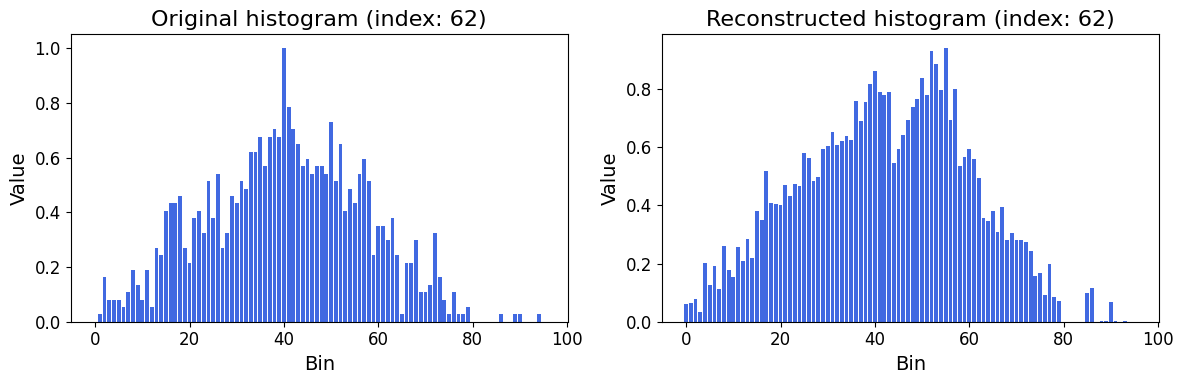

In [48]:
import torch.nn as nn
device = 'cpu'
generator.eval()
encoder.eval()
idx = 62

with torch.no_grad():
    x = full_dataset[idx].to(device)
    pred = generator(encoder(x.reshape(1,1,96)))

    criterion = nn.MSELoss()
    loss = criterion(pred, x).item()

original = x.squeeze().cpu().numpy()
reconstructed = pred.squeeze().cpu().numpy()

_, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(original)), original, zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("Value")

axes[1].bar(range(len(reconstructed)), reconstructed, zorder=1, color='royalblue')
axes[1].set_title(f"Reconstructed histogram (index: {idx})")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()

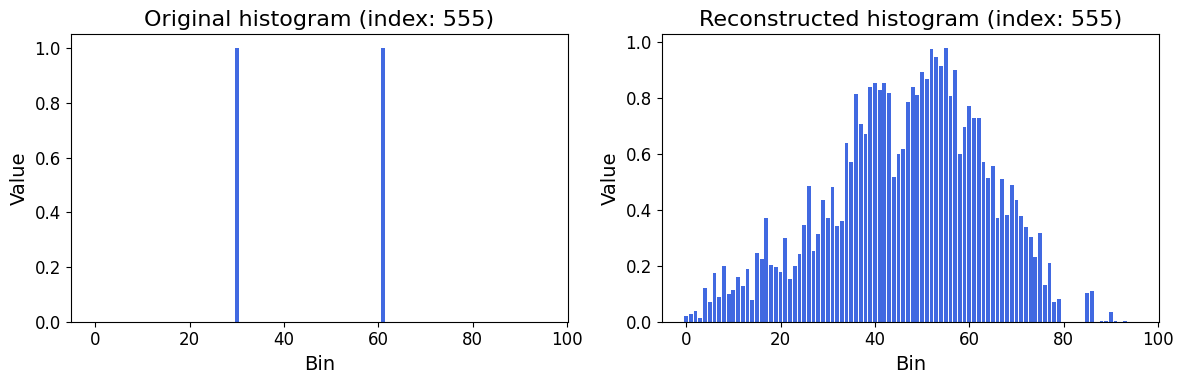

In [57]:
device = 'cpu'
generator.eval()
encoder.eval()
idx = 555

with torch.no_grad():
    x = full_dataset[idx].to(device)
    pred = generator(encoder(x.reshape(1,1,96)))

    criterion = nn.MSELoss()
    loss = criterion(pred, x).item()

original = x.squeeze().cpu().numpy()
reconstructed = pred.squeeze().cpu().numpy()

_, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(range(len(original)), original, zorder=1, color='royalblue')
axes[0].set_title(f"Original histogram (index: {idx})")
axes[0].set_xlabel("Bin")
axes[0].set_ylabel("Value")

axes[1].bar(range(len(reconstructed)), reconstructed, zorder=1, color='royalblue')
axes[1].set_title(f"Reconstructed histogram (index: {idx})")
axes[1].set_xlabel("Bin")
axes[1].set_ylabel("Value")

plt.tight_layout()
plt.show()